In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,           # Convolutional layers
    MaxPooling2D,     # Pooling layers
    Dropout,          # Dropout layers
    BatchNormalization, # Batch normalization
    Flatten,
    Dense,            # Dense output layer
    Input
)

In [10]:
DATASET_PATH = r"D:\Tejashri\Aeriel\classification_dataset"

In [11]:
#Inspecting the Dataset

SPLITS = ['train', 'valid', 'test']
CLASSES = ['bird', 'drone']
print("=" * 50)
print("DATASET FOLDER STRUCTURE")
print("=" * 50)
for split in SPLITS:
    split_path = os.path.join(DATASET_PATH, split)
    print(f"\n📁 {split}/")
    for cls in CLASSES:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            print(f"   ├── {cls}/   →   {len(files)} images")
        else:
            print(f"   ├── {cls}/   →   FOLDER NOT FOUND")

DATASET FOLDER STRUCTURE

📁 train/
   ├── bird/   →   1414 images
   ├── drone/   →   1248 images

📁 valid/
   ├── bird/   →   217 images
   ├── drone/   →   225 images

📁 test/
   ├── bird/   →   121 images
   ├── drone/   →   94 images


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ['bird', 'drone']

In [13]:
# AUGMENTED generator — for TRAIN data only
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize to [0, 1]
    rotation_range=30,           # Rotate up to 30 degrees randomly
    horizontal_flip=True,        # Flip left-right randomly
    vertical_flip=True,          # Flip up-down (birds/drones can appear any orientation)
    zoom_range=0.2,              # Zoom in/out up to 20%
    brightness_range=[0.7, 1.3], # Brightness: darker (0.7) to brighter (1.3)
    width_shift_range=0.1,       # Shift horizontally up to 10% (simulates cropping)
    height_shift_range=0.1,      # Shift vertically up to 10%
    shear_range=0.1,             # Shear transformation
    fill_mode='nearest'          # Fill empty pixels after rotation/shift
)


# NO augmentation for VALID and TEST — only normalize

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
# ============================================================
# generators for CNN
# ============================================================
train_generator = train_datagen.flow_from_directory(
    directory=f'{DATASET_PATH}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    shuffle=True,
    seed=42
)

valid_generator = val_test_datagen.flow_from_directory(
    directory=f'{DATASET_PATH}/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    directory=f'{DATASET_PATH}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    shuffle=False
)

print(f"Class mapping  : {train_generator.class_indices}")
print(f"Train samples  : {train_generator.n}")
print(f"Valid samples  : {valid_generator.n}")
print(f"Test  samples  : {test_generator.n}")

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class mapping  : {'bird': 0, 'drone': 1}
Train samples  : 2662
Valid samples  : 442
Test  samples  : 215


In [15]:
# ============================================================
# VERIFY AUGMENTED BATCH STATS
# ============================================================
batch_imgs, batch_labels = next(iter(train_generator))

print("\n=== Augmented Batch Verification ===")
print(f"Batch shape : {batch_imgs.shape}")        # (32, 224, 224, 3)
print(f"Pixel min   : {batch_imgs.min():.4f}")    # Should be ~0.0
print(f"Pixel max   : {batch_imgs.max():.4f}")    # Should be ~1.0
print(f"Label dist  : Bird={int((batch_labels==0).sum())}  Drone={int((batch_labels==1).sum())}")


=== Augmented Batch Verification ===
Batch shape : (32, 224, 224, 3)
Pixel min   : 0.0000
Pixel max   : 1.0000
Label dist  : Bird=16  Drone=16


In [16]:
# ============================================================
# CUSTOM CNN MODEL
# ============================================================
model = Sequential([

    Input(shape=(224, 224, 3)),

    # ────────────────────────────────
    # BLOCK 1 — Conv + Pool + Dropout
    # ────────────────────────────────
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # ────────────────────────────────
    # BLOCK 2 — Conv + Pool + Dropout
    # ────────────────────────────────
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # ────────────────────────────────
    # BLOCK 3 — Conv + Pool + Dropout
    # ────────────────────────────────
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    # ────────────────────────────────
    # BLOCK 4 — Conv + Pool + Dropout
    # ────────────────────────────────
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    # ────────────────────────────────
    # DENSE OUTPUT LAYER
    # ────────────────────────────────
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),

    # Output — Binary: Bird (0) or Drone (1)
    Dense(1, activation='sigmoid')

], name='Custom_CNN')

# ────────────────────────────────
# COMPILE
# ────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,236,929 (50.49 MB)

 Trainable params: 13,235,457 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [17]:
# ============================================================
# CALLBACKS
# ============================================================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

cnn_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/custom_cnn_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [18]:
# ============================================================
# TRAIN
# ============================================================
print("="*45)
print("  TRAINING: Custom CNN")
print("="*45)

history_cnn = model.fit(
    train_generator,
    epochs=30,
    validation_data=valid_generator,
    callbacks=cnn_callbacks,
    verbose=1
)

  TRAINING: Custom CNN
Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6330 - loss: 0.9201 - precision: 0.6127 - recall: 0.6068
Epoch 1: val_accuracy improved from None to 0.49095, saving model to saved_models/custom_cnn_best.keras

Epoch 1: finished saving model to saved_models/custom_cnn_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.6578 - loss: 0.7695 - precision: 0.6391 - recall: 0.6202 - val_accuracy: 0.4910 - val_loss: 9.7018 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6598 - loss: 0.7238 - precision: 0.6448 - recall: 0.6106
Epoch 2: val_accuracy did not improve from 0.49095
84/84 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.6875 - loss: 0.6662 - precision: 0.6802 - recall: 0.6290 - val_accuracy: 0.4910 - val_loss: 1.1454 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - a

In [21]:

SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)
model.save(f'{SAVE_DIR}/custom_cnn_best.keras')
print(f"✅ Model saved: {os.path.abspath(f'{SAVE_DIR}/custom_cnn_best.keras')}")

✅ Model saved: C:\Users\Super\anaconda_projects\aerial\saved_models\custom_cnn_best.keras


In [27]:
# ============================================================
# TRANSFER LEARNING GENERATORS
# Each model needs its own specific preprocess_input
# ============================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

DATASET_PATH = r"D:\Tejashri\Aeriel\classification_dataset"
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
CLASSES      = ['bird', 'drone']

# ── Augmentation settings (same as before, but uses preprocess_input instead of rescale)
def make_tl_generators(preprocess_fn, model_name):

    # Train — with augmentation + model-specific preprocessing
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=30,
        horizontal_flip=True,
        vertical_flip=True,
        zoom_range=0.2,
        brightness_range=[0.7, 1.3],
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        fill_mode='nearest'
    ).flow_from_directory(
        f'{DATASET_PATH}/train',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASSES,
        shuffle=True,
        seed=42
    )

    # Valid — only preprocessing, no augmentation
    val_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    ).flow_from_directory(
        f'{DATASET_PATH}/valid',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASSES,
        shuffle=False
    )

    # Test — only preprocessing, no augmentation
    test_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    ).flow_from_directory(
        f'{DATASET_PATH}/test',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASSES,
        shuffle=False
    )

    print(f"✅ {model_name} generators ready — Train: {train_gen.n} | Valid: {val_gen.n} | Test: {test_gen.n}")
    return train_gen, val_gen, test_gen


# ── Create generators for each TL model
train_resnet, val_resnet, test_resnet = make_tl_generators(resnet_preprocess,    'ResNet50')
train_mobile, val_mobile, test_mobile = make_tl_generators(mobilenet_preprocess, 'MobileNetV2')
train_effnet, val_effnet, test_effnet = make_tl_generators(efficientnet_preprocess, 'EfficientNetB0')

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
✅ ResNet50 generators ready — Train: 2662 | Valid: 442 | Test: 215
Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
✅ MobileNetV2 generators ready — Train: 2662 | Valid: 442 | Test: 215
Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
✅ EfficientNetB0 generators ready — Train: 2662 | Valid: 442 | Test: 215


In [28]:
# ============================================================
# TRANSFER LEARNING MODEL BUILDER
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0

def build_tl_model(base_model_fn, input_shape=(224, 224, 3), name='model'):

    # ── Load pretrained base (ImageNet weights, no top classifier)
    base = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # ── Phase 1: Freeze ALL base layers
    base.trainable = False

    # ── Add custom classification head
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)   # Bird=0, Drone=1

    model = Model(inputs=base.input, outputs=output, name=name)

    # ── Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model, base


# ── Build each model
resnet_model, resnet_base = build_tl_model(ResNet50,       name='ResNet50')
mobile_model, mobile_base = build_tl_model(MobileNetV2,    name='MobileNetV2')
effnet_model, effnet_base = build_tl_model(EfficientNetB0, name='EfficientNetB0')

# ── Check trainable layers
for name, m in [('ResNet50', resnet_model),
                ('MobileNetV2', mobile_model),
                ('EfficientNetB0', effnet_model)]:
    total     = len(m.layers)
    trainable = sum(1 for l in m.layers if l.trainable)
    frozen    = total - trainable
    print(f"{name:<18} Total: {total}  Trainable: {trainable}  Frozen: {frozen}")

ResNet50           Total: 182  Trainable: 7  Frozen: 175
MobileNetV2        Total: 161  Trainable: 7  Frozen: 154
EfficientNetB0     Total: 245  Trainable: 7  Frozen: 238


In [29]:
# ============================================================
# QUICK SUMMARY — top layers only
# ============================================================
for name, m in [('ResNet50', resnet_model),
                ('MobileNetV2', mobile_model),
                ('EfficientNetB0', effnet_model)]:
    print(f"\n{'='*50}")
    print(f"  {name} — Parameter Count")
    print(f"{'='*50}")
    total     = m.count_params()
    trainable = sum(tf.size(w).numpy() for w in m.trainable_weights)
    frozen    = total - trainable
    print(f"  Total params      : {total:,}")
    print(f"  Trainable params  : {trainable:,}  ← only the head")
    print(f"  Frozen params     : {frozen:,}  ← ImageNet base")


  ResNet50 — Parameter Count
  Total params      : 24,136,961
  Trainable params  : 545,153  ← only the head
  Frozen params     : 23,591,808  ← ImageNet base

  MobileNetV2 — Parameter Count
  Total params      : 2,607,553
  Trainable params  : 347,009  ← only the head
  Frozen params     : 2,260,544  ← ImageNet base

  EfficientNetB0 — Parameter Count
  Total params      : 4,399,140
  Trainable params  : 347,009  ← only the head
  Frozen params     : 4,052,131  ← ImageNet base


In [33]:
# ============================================================
# CALLBACKS
# ============================================================
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
import os

SAVE_DIR = '/content/drive/MyDrive/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{SAVE_DIR}/{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

print("✅ Callbacks ready: EarlyStopping | ModelCheckpoint | ReduceLROnPlateau")

✅ Callbacks ready: EarlyStopping | ModelCheckpoint | ReduceLROnPlateau


In [5]:
# ============================================================
# PHASE 1 — Train only the head (base fully frozen)
# Fast convergence, small number of trainable params
# ============================================================

def train_phase1(m, train_gen, val_gen, model_name, epochs=20):
    print(f"\n{'='*50}")
    print(f"  PHASE 1 TRAINING: {model_name}")
    print(f"{'='*50}")
    history = m.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=get_callbacks(f'{model_name}_phase1'),
        verbose=1
    )
    return history

hist_resnet_p1 = train_phase1(resnet_model, train_resnet, val_resnet, 'ResNet50')
hist_mobile_p1 = train_phase1(mobile_model, train_mobile, val_mobile, 'MobileNetV2')
hist_effnet_p1 = train_phase1(effnet_model, train_effnet, val_effnet, 'EfficientNetB0')


  PHASE 1 TRAINING: ResNet50
Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8508 - loss: 0.3772 - precision: 0.8553 - recall: 0.8234
Epoch 1: val_accuracy improved from None to 0.98416, saving model to /content/drive/MyDrive/saved_models/ResNet50_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/ResNet50_phase1_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.9125 - loss: 0.2289 - precision: 0.9129 - recall: 0.8990 - val_accuracy: 0.9842 - val_loss: 0.0567 - val_precision: 0.9781 - val_recall: 0.9911 - learning_rate: 0.0010
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9496 - loss: 0.1382 - precision: 0.9553 - recall: 0.9416
Epoch 2: val_accuracy did not improve from 0.98416
84/84 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.9530 - loss: 0.1258 - precision: 0.9496 - recall: 0.9503 - val_accuracy: 0.9751 - val_loss: 0.0670 - val_precision: 0.9954 - val_recall: 0.9556 - learning_rate: 0.0010
Epoch

In [6]:
# Save each model individually
resnet_model.save('ResNet50_phase1.keras')
mobile_model.save('MobileNetV2_phase1.keras')
effnet_model.save('EfficientNetB0_phase1.keras')

print("All models saved successfully!")

All models saved successfully!


In [31]:
from tensorflow.keras.models import load_model

# Reload the models
resnet_model = load_model('ResNet50_phase1.keras')
mobile_model = load_model('MobileNetV2_phase1.keras')
effnet_model = load_model('EfficientNetB0_phase1.keras')

print("Models reloaded and ready for Phase 2!")

Models reloaded and ready for Phase 2!


In [35]:
# ============================================================
# CHECK GENERATOR LENGTHS
# ============================================================
print(f"test_generator : {test_generator.n} images  | path: {test_generator.directory}")
print(f"test_resnet    : {test_resnet.n} images  | path: {test_resnet.directory}")
print(f"test_mobile    : {test_mobile.n} images  | path: {test_mobile.directory}")
print(f"test_effnet    : {test_effnet.n} images  | path: {test_effnet.directory}")

test_generator : 215 images  | path: D:\Tejashri\Aeriel\classification_dataset/test
test_resnet    : 0 images  | path: your\path\to\classification_dataset/test
test_mobile    : 0 images  | path: your\path\to\classification_dataset/test
test_effnet    : 0 images  | path: your\path\to\classification_dataset/test


In [32]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score
)

CLASSES = ['bird', 'drone']

In [36]:
# ============================================================
# RECREATE TL TEST GENERATORS
# ============================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

DATASET_PATH = r"D:\Tejashri\Aeriel\classification_dataset"
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
CLASSES      = ['bird', 'drone']

test_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess
).flow_from_directory(
    f'{DATASET_PATH}/test', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary',
    classes=CLASSES, shuffle=False
)

test_mobile = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess
).flow_from_directory(
    f'{DATASET_PATH}/test', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary',
    classes=CLASSES, shuffle=False
)

test_effnet = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess
).flow_from_directory(
    f'{DATASET_PATH}/test', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary',
    classes=CLASSES, shuffle=False
)

print("✅ test_resnet  ready")
print("✅ test_mobile  ready")
print("✅ test_effnet  ready")

Found 215 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
✅ test_resnet  ready
✅ test_mobile  ready
✅ test_effnet  ready



  EVALUATING: Custom_CNN
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step

Classification Report:
              precision    recall  f1-score   support

        bird     0.8968    0.9339    0.9150       121
       drone     0.9101    0.8617    0.8852        94

    accuracy                         0.9023       215
   macro avg     0.9035    0.8978    0.9001       215
weighted avg     0.9026    0.9023    0.9020       215

  ROC-AUC Score : 0.9574


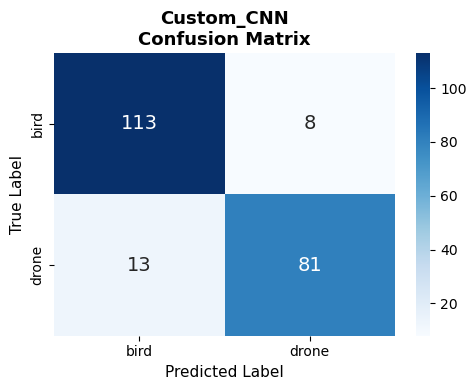


  EVALUATING: ResNet50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step

Classification Report:
              precision    recall  f1-score   support

        bird     0.9916    0.9752    0.9833       121
       drone     0.9688    0.9894    0.9789        94

    accuracy                         0.9814       215
   macro avg     0.9802    0.9823    0.9811       215
weighted avg     0.9816    0.9814    0.9814       215

  ROC-AUC Score : 0.9980


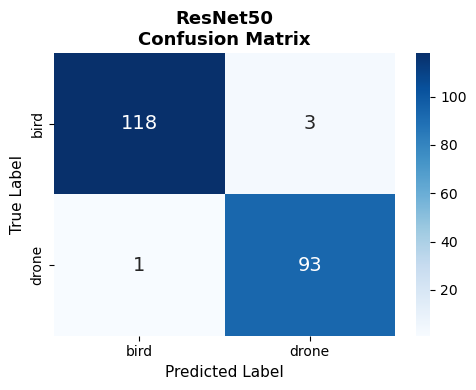


  EVALUATING: MobileNetV2
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 736ms/step

Classification Report:
              precision    recall  f1-score   support

        bird     0.9832    0.9669    0.9750       121
       drone     0.9583    0.9787    0.9684        94

    accuracy                         0.9721       215
   macro avg     0.9708    0.9728    0.9717       215
weighted avg     0.9723    0.9721    0.9721       215

  ROC-AUC Score : 0.9967


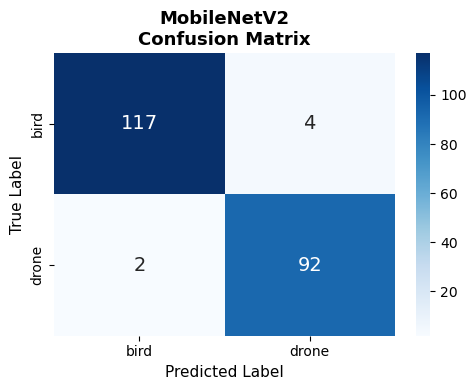


  EVALUATING: EfficientNetB0
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Classification Report:
              precision    recall  f1-score   support

        bird     0.9597    0.9835    0.9714       121
       drone     0.9780    0.9468    0.9622        94

    accuracy                         0.9674       215
   macro avg     0.9688    0.9651    0.9668       215
weighted avg     0.9677    0.9674    0.9674       215

  ROC-AUC Score : 0.9953


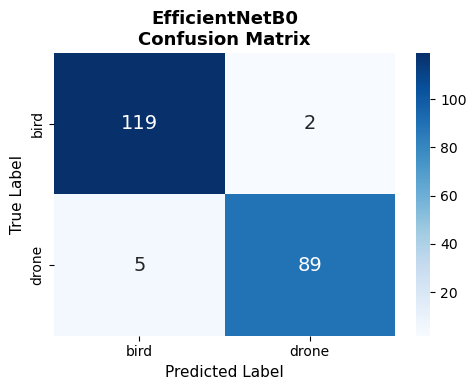

In [37]:
# ============================================================
# EVALUATE ALL 4 MODELS
# ============================================================
results = []

results.append(evaluate_model(model,        test_generator, 'Custom_CNN'))
results.append(evaluate_model(resnet_model, test_resnet,    'ResNet50'))
results.append(evaluate_model(mobile_model, test_mobile,    'MobileNetV2'))
results.append(evaluate_model(effnet_model, test_effnet,    'EfficientNetB0'))



In [38]:
# ============================================================
# SAVE BEST MODEL — ResNet50 for Streamlit
# ============================================================
import os

DEPLOY_DIR = 'streamlit_app'
os.makedirs(DEPLOY_DIR, exist_ok=True)

# Save best model
resnet_model.save(f'{DEPLOY_DIR}/best_model.keras')

# Save model info
with open(f'{DEPLOY_DIR}/model_info.txt', 'w') as f:
    f.write("model_name=ResNet50\n")
    f.write("img_size=224\n")
    f.write("classes=bird,drone\n")

print(f"✅ Best model saved : {os.path.abspath(DEPLOY_DIR)}/best_model.keras")
print(f"✅ Model info saved : {DEPLOY_DIR}/model_info.txt")
print(f"   Model    : ResNet50")
print(f"   Accuracy : 98.14%")
print(f"   F1-Score : 0.9814")
print(f"   ROC-AUC  : 0.9980")
print(f"\n   Ready for Streamlit deployment!")

✅ Best model saved : C:\Users\Super\anaconda_projects\aerial\streamlit_app/best_model.keras
✅ Model info saved : streamlit_app/model_info.txt
   Model    : ResNet50
   Accuracy : 98.14%
   F1-Score : 0.9814
   ROC-AUC  : 0.9980

   Ready for Streamlit deployment!
